# ftir_47 — HIPS blank lines belong to deployed calibration lines, not lots: the network audit and the Pasadena correction

## tl;dr

The 08-23 blank-line recompute pooled every blank in a lot into one quadratic, and that is
not a blank response curve. Lot 251's 373 blanks belong to **three deployed calibration
lines** — 2423.6 − 6.033·R1 (blanks R1 224–265, Oct 2022–Mar 2023), 1416.2 − 2.783·R1
(R1 134–206, May 2023–Apr 2024) and 1397.0 − 2.687·R1 (R1 138–232, Aug 2024–Mar 2026) —
whose blank R1 ranges share no common interval; each is fitted by its own line to 5–10
counts rms while the pooled quadratic scatters 32 counts (linear: 43) and bends upward
above R1 ≈ 240, where only the 2022–23 line has blanks. Lots 248 and 250 have the same
structure (per-line rms 4–8 counts, pooled 31–40). Keyed per line, the shipped Fabs
reproduce exactly (max |Δ| 0.0000 Mm⁻¹ over 3,047 samples) and both quadratic headlines in
`OFFSET_ADJUDICATION_2026-08-23.md` §5/§5b fall. **Pasadena does not dissolve:** under the
adjudication's own configuration (ocec-450 × AIRSpec, k=9) the pooled quadratic gives
0.91x + 0.67 exactly as quoted — because it inflates the 56/158 Pasadena filters on the
2423.6 line by 80% (median Fabs 4.84 → 8.72 Mm⁻¹) — while each filter's own line's
quadratic gives **3.04 ± 0.19x − 0.15 ± 0.10** (deployed 3.15 ± 0.19x); the winner
ocec-440 k=8 goes 3.27 → **3.18 ± 0.20**, the locked ocec-800 k=5 2.04 → **1.94 ± 0.14**.
**Addis's −1.27 ± 0.17 was the same pooled artifact** (reproduced here): the per-line
quadratic gives −1.48 ± 0.18 in that configuration (deployed −1.51), −1.37 ± 0.18 for the
winner (deployed −1.40) and −1.84 ± 0.20 for the locked model (deployed −1.87) — the
blank-line shape moves the Addis intercept by ≤ 0.03 µg/m³, not 0.24, and 44% of Addis
filters (not 36%) sit below their own line's blank R1 range. Network-wide (27 sites,
2,998 samples on a fitted line) 43% of samples are on a line that is not their lot's modal
line; 14.9% fall outside their own line's blank R1 range (9.0% heavier than any blank:
BDDU 49%, ETAD 44%, IDBD 30%, INDH 18%; 5.9% lighter: CAHA 39%, KRSE 25%, KRUL 23%); and
the pooled quadratic shifts Fabs by a median 0.67 Mm⁻¹ (p90 4.19) against 0.29 (p90 0.83)
for the per-line quadratic — ILHA 3.2, ILNZ 2.0, Pasadena 0.9 Mm⁻¹ median. Two references
cannot be audited from local files: the ETBI reconstructed holdout's line is inferred from
analysis dates, and Adama's lot-245 line (1464.2 − 2.554·R1) has zero blanks in the SPARTAN
export and zero rows in the raw `hips.Results` pull. Rule for the explorer: key blank lines
on (lot, Intercept, Slope), never on lot.

## Context & Methods

SPARTAN's HIPS scattering correction is a blank regression line: τ = ln((Intercept +
Slope·R1)/T1), Fabs = 100·τ·A/V, with (Intercept, Slope) fitted to field/lab blanks
(`OFFSET_ADJUDICATION_2026-08-23.md` §5b; formula verified bit-exact against the raw
`hips.Results` pull in `HIPS_RAW_PULL_2026-08-23.md`). The 08-23 blank-line test recomputed
Fabs under alternative blank lines — lot-common linear and lot quadratic — and the
quadratic variant produced two headline numbers: Addis −1.27 ± 0.17 and "Pasadena's slope
anomaly dissolves" (3.15x → 0.91x).

Both came from `calibration_explorer/hips_lab.py` at commit 8561843, whose `blank_lines()`
grouped blanks **by LotId only**. But a manufacturing lot is re-calibrated whenever the
instrument changes (`hips.CalibrationSets`: reconfiguration, "apparent shift", collimator
replacement, lab move — `scripts/AQRC_DB_NOTES.md`), and every filter in the batch export
carries the specific (Intercept, Slope) it was reduced with. Lot 251 alone holds three
deployed lines whose blanks occupy different R1 regimes because the instrument gain changed
between them. A quadratic pooled over all of them fits the *gain history*, not the
blank response, and its shape between regimes is an artifact.

This notebook is the audit: (1) the blank ledger per deployed line versus per lot,
(2) every SPARTAN site's exposure to the difference, (3) the five explorer targets
re-fitted (York, per-filter σ) under deployed / per-line linear / per-line quadratic /
lot-pooled quadratic lines for the sweep-winner and the locked f(X) configurations plus the
adjudication's own configuration, (4) the lines that cannot be audited from local files,
and (5) the keying rule the explorer now follows.

**Requires the calibration explorer on :5058** (predictions come from `/api/run`, so the
f(X) values are exactly the app's).

### Key assumptions

- A "deployed line" is the (LotId, Intercept, Slope) triple shipped on each row of
  `SPARTAN_HIPS_Batch1-51.v2.csv`; blanks are rows with FilterType FB or LB. Lines with
  fewer than 5 blanks get no refit (same threshold as `hips_lab.blank_lines()`).
- Blank refits are ordinary least squares of T1 on R1 (linear, quadratic), exactly as in
  `hips_lab`; the lot-pooled quadratic is the 8561843 construction re-implemented here.
- York fits use MAC = 10, x = Fabs/10 with σ_x from `hips_lab.sigma_fabs` (per-site
  σ² = a² + (b·F)² models; ETBI uses the pooled non-ETAD model) and σ_y inflated to MSWD = 1.
- Predictions f(X) are taken from the explorer unchanged; only the HIPS side is recomputed.
- "Extrapolation" means a sample's R1 lies outside the R1 range of the blanks that define
  its own line. Blank R1 ranges are what the batch file contains, not the lab's full
  calibration set (`hips.CalibrationSetFilters` was not pulled).

In [1]:
%matplotlib inline
import json
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))
REPO = Path('.').resolve()
while not (REPO / 'calibration_explorer').exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / 'calibration_explorer'))

import hips_lab  # noqa: E402
import phase3_common as pc  # noqa: E402
from plotting import apply_default_style  # noqa: E402

apply_default_style()
OUT = Path('output/tables/ftir47')
PLOTS = Path('output/plots/ftir47')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

API = 'http://127.0.0.1:5058/api/run'
MAC = hips_lab.MAC
MIN_BLANKS = 5
CONFIGS = {
    'winner ocec-440 AIRSpec k=8': {'cohort': 'ocec', 'cutoff': 440, 'selection_space': 'raw',
                                    'spectra': 'airspec', 'mode': 'site_heldout', 'k': 8},
    'locked ocec-800 AIRSpec k=5': {'cohort': 'ocec', 'cutoff': 800, 'selection_space': 'raw',
                                    'spectra': 'airspec', 'mode': 'site_heldout', 'k': 5},
    'adjudication ocec-450 AIRSpec k=9': {'cohort': 'ocec', 'cutoff': 450, 'selection_space': 'raw',
                                          'spectra': 'airspec', 'mode': 'site_heldout', 'k': 9},
}
TARGETS = [('addis', 'ETAD', 'Addis'), ('etbi', 'ETBI', 'Bishoftu'), ('chts', 'CHTS', 'Beijing'),
           ('indh', 'INDH', 'Delhi'), ('uspa', 'USPA', 'Pasadena')]
VARIANTS = ['deployed', 'line_lin', 'line_quad', 'lot_quad']
LINE_COLORS = ['#C0392B', '#2980B9', '#27AE60', '#8E44AD', '#E67E22', '#7F8C8D']

## Data

The batch export (every SPARTAN site, blanks and samples, deployed line per row) and the
raw `hips.Results` pull (28 sites, raw T/R, lot id, no deployed line).

In [2]:
batch = pd.read_csv(pc.PATHS.spartan_hips_primary, encoding='cp1252')
batch['LotId'] = batch['LotId'].astype(str).str.strip()
batch['has_line'] = batch['Intercept'].notna() & batch['Slope'].notna()
batch['line_id'] = [hips_lab._line_id(hips_lab._line_key(lot, i, s)) if ok else None
                    for lot, i, s, ok in zip(batch['LotId'], batch['Intercept'],
                                             batch['Slope'], batch['has_line'])]
batch['AnalysisDate'] = pd.to_datetime(batch['AnalysisDate'], errors='coerce')
is_blank = batch['FilterType'].isin(['FB', 'LB'])
blanks = batch[is_blank & batch['has_line']].dropna(subset=['R1', 'T1']).query('T1 > 0').copy()
samples = batch[~is_blank].copy()
samples['dv'] = 100.0 * samples['DepositArea'] / samples['Volume']

raw_pull = pd.read_csv(pc.PATHS.etad_dir.parent / 'SPARTAN HIPS pulls' / 'spartan_hips_raw_all.csv',
                       low_memory=False)
print(f'batch export: {len(batch)} rows, {batch["Site"].nunique()} sites, '
      f'{is_blank.sum()} blanks ({(is_blank & ~batch["has_line"]).sum()} without a deployed line), '
      f'{len(samples)} samples ({(~samples["has_line"]).sum()} without a deployed line)')
print(f'raw pull: {len(raw_pull)} rows, {raw_pull["SiteCode"].nunique()} sites, '
      f'lots {sorted(raw_pull["ExternalLotId"].astype(str).unique())}')

# Fabs = 100·τ·A/V with τ from the deployed line: confirm on the shipped rows
chk = samples[samples['has_line'] & samples['Fabs'].notna() & (samples['Volume'] > 0)]
tau_chk = np.log((chk['Intercept'] + chk['Slope'] * chk['R1']) / chk['T1'])
fabs_chk = tau_chk * chk['dv']
print(f'deployed-line recompute vs shipped Fabs: max |diff| = '
      f'{np.nanmax(np.abs(fabs_chk - chk["Fabs"])):.4f} Mm⁻¹ over {len(chk)} samples')

batch export: 3963 rows, 27 sites, 582 blanks (7 without a deployed line), 3381 samples (56 without a deployed line)
raw pull: 6876 rows, 28 sites, lots ['241', '241a', '248', '250', '251', '253']
deployed-line recompute vs shipped Fabs: max |diff| = 0.0000 Mm⁻¹ over 3047 samples


## Results

### 1. The blank ledger: per deployed line, then per lot

One row per (lot, Intercept, Slope). `rms_deployed` is the scatter of the blanks about the
line actually shipped; `rms_lin` / `rms_quad` are refits on the same blanks. `curvature` is
the sign of the quadratic's R1² coefficient.

In [3]:
def refit(R, T):
    lin = np.polyfit(R, T, 1)
    quad = np.polyfit(R, T, 2)
    return lin, quad, float(np.std(T - np.polyval(lin, R))), float(np.std(T - np.polyval(quad, R)))


line_rows, LINE_FIT = [], {}
for line_id, g in blanks.groupby('line_id'):
    R, T = g['R1'].to_numpy(float), g['T1'].to_numpy(float)
    row = {'line_id': line_id, 'lot': g['LotId'].iloc[0],
           'intercept': float(g['Intercept'].iloc[0]), 'slope': float(g['Slope'].iloc[0]),
           'n_blanks': len(g), 'n_FB': int((g['FilterType'] == 'FB').sum()),
           'n_LB': int((g['FilterType'] == 'LB').sum()),
           'n_sites': int(g['Site'].nunique()),
           'analysis_from': g['AnalysisDate'].min().date(), 'analysis_to': g['AnalysisDate'].max().date(),
           'R1_min': float(R.min()), 'R1_max': float(R.max()),
           'T1_min': float(T.min()), 'T1_max': float(T.max()),
           'rms_deployed': float(np.std(T - float(g['Intercept'].iloc[0]) - float(g['Slope'].iloc[0]) * R))}
    if len(g) >= MIN_BLANKS:
        lin, quad, rms_lin, rms_quad = refit(R, T)
        LINE_FIT[line_id] = {'lin': lin, 'quad': quad, 'R1_min': R.min(), 'R1_max': R.max()}
        row.update({'rms_lin': rms_lin, 'rms_quad': rms_quad,
                    'quad_a2': float(quad[0]), 'curvature': 'convex (+)' if quad[0] > 0 else 'concave (−)',
                    'n_samples_on_line': int((samples['line_id'] == line_id).sum())})
    else:
        row.update({'rms_lin': np.nan, 'rms_quad': np.nan, 'quad_a2': np.nan,
                    'curvature': f'unfit (<{MIN_BLANKS} blanks)',
                    'n_samples_on_line': int((samples['line_id'] == line_id).sum())})
    line_rows.append(row)
line_ledger = pd.DataFrame(line_rows).sort_values(['lot', 'analysis_from']).reset_index(drop=True)

# cross-check against the module the explorer serves
module_lines = hips_lab.blank_lines()
for line_id, fit in LINE_FIT.items():
    assert np.allclose(fit['quad'], module_lines[line_id]['quad']), line_id
    assert np.allclose(fit['lin'], module_lines[line_id]['lin']), line_id
print(f'{len(LINE_FIT)} deployed lines with ≥{MIN_BLANKS} blanks; refits identical to '
      f'hips_lab.blank_lines() ({len(module_lines)} lines served)')
line_ledger.to_csv(OUT / 'blank_ledger_per_line.csv', index=False)
display(line_ledger.drop(columns=['quad_a2']).round(1))

9 deployed lines with ≥5 blanks; refits identical to hips_lab.blank_lines() (9 lines served)


,line_id,lot,intercept,slope,n_blanks,n_FB,n_LB,n_sites,analysis_from,analysis_to,R1_min,R1_max,T1_min,T1_max,rms_deployed,rms_lin,rms_quad,curvature,n_samples_on_line
0,241a|I=1481.000|S=-2.6620,241a,1481.0,-2.7,2,2,0,1,2025-07-08,2025-07-08,146.0,161.0,1052.0,1091.0,0.5,NaN,NaN,unfit (<5 blanks),14
1,248|I=2262.000|S=-5.3200,248,2262.0,-5.3,16,16,0,7,2022-10-20,2023-03-17,230.0,266.0,858.0,1045.0,7.6,7.6,7.2,convex (+),114
2,248|I=1383.200|S=-2.5440,248,1383.2,-2.5,27,23,4,10,2023-05-03,2023-09-22,157.0,201.0,871.0,985.0,4.2,3.9,3.9,convex (+),159
3,248|I=1391.100|S=-2.6260,248,1391.1,-2.6,2,2,0,2,2025-03-13,2025-03-13,146.0,188.0,901.0,1017.0,2.9,NaN,NaN,unfit (<5 blanks),14
4,250|I=2551.000|S=-6.6260,250,2551.0,-6.6,13,9,4,4,2022-10-25,2022-12-08,223.0,237.0,985.0,1072.0,6.2,6.0,5.9,concave (−),61
5,250|I=2377.900|S=-5.8440,250,2377.9,-5.8,9,7,2,5,2023-02-23,2023-02-23,238.0,247.0,938.0,988.0,3.7,3.7,3.3,convex (+),49
6,250|I=1438.100|S=-2.9320,250,1438.1,-2.9,47,41,6,10,2023-05-11,2024-04-30,130.0,175.0,922.0,1064.0,4.2,3.9,3.7,convex (+),286
7,250|I=1437.100|S=-2.9780,250,1437.1,-3.0,3,3,0,2,2024-08-08,2024-12-19,148.0,172.0,925.0,1005.0,6.3,NaN,NaN,unfit (<5 blanks),21
8,251|I=2423.600|S=-6.0330,251,2423.6,-6.0,63,53,10,8,2022-10-20,2023-03-17,224.0,265.0,845.0,1078.0,7.1,6.2,5.3,convex (+),369
9,251|I=1416.200|S=-2.7830,251,1416.2,-2.8,162,122,40,20,2023-05-03,2024-04-30,134.0,206.0,841.0,1038.0,5.0,5.0,4.6,convex (+),854


In [4]:
lot_rows, LOT_FIT = [], {}
for lot, g in blanks.groupby('LotId'):
    if len(g) < MIN_BLANKS:
        continue
    R, T = g['R1'].to_numpy(float), g['T1'].to_numpy(float)
    lin, quad, rms_lin, rms_quad = refit(R, T)
    LOT_FIT[lot] = {'lin': lin, 'quad': quad, 'R1_min': R.min(), 'R1_max': R.max()}
    sub = line_ledger[(line_ledger['lot'] == lot) & line_ledger['rms_lin'].notna()]
    # do the fitted lines' blank R1 ranges overlap at all?
    overlap = (sub['R1_min'].max() <= sub['R1_max'].min()) if len(sub) > 1 else np.nan
    lot_rows.append({'lot': lot, 'n_blanks': len(g), 'n_deployed_lines': int(g['line_id'].nunique()),
                     'n_lines_fitted': len(sub),
                     'analysis_from': g['AnalysisDate'].min().date(), 'analysis_to': g['AnalysisDate'].max().date(),
                     'R1_min': float(R.min()), 'R1_max': float(R.max()),
                     'T1_min': float(T.min()), 'T1_max': float(T.max()),
                     'rms_lin': rms_lin, 'rms_quad': rms_quad, 'quad_a2': float(quad[0]),
                     'curvature': 'convex (+)' if quad[0] > 0 else 'concave (−)',
                     'all_fitted_lines_share_an_R1_interval': overlap,
                     'n_samples_in_lot': int((samples['LotId'] == lot).sum())})
lot_ledger = pd.DataFrame(lot_rows)
lot_ledger.to_csv(OUT / 'blank_ledger_per_lot_pooled.csv', index=False)
display(lot_ledger.drop(columns=['quad_a2']).round(1))

multi = lot_ledger[lot_ledger['n_lines_fitted'] > 1]
print('\nlots with more than one fitted deployed line: ' + ', '.join(
    f'{r.lot} ({r.n_lines_fitted} lines, pooled rms lin/quad {r.rms_lin:.0f}/{r.rms_quad:.0f} counts, '
    f'per-line rms {line_ledger[(line_ledger.lot == r.lot)].rms_lin.min():.0f}–'
    f'{line_ledger[(line_ledger.lot == r.lot)].rms_lin.max():.0f})'
    for r in multi.itertuples()))

,lot,n_blanks,n_deployed_lines,n_lines_fitted,analysis_from,analysis_to,R1_min,R1_max,T1_min,T1_max,rms_lin,rms_quad,curvature,all_fitted_lines_share_an_R1_interval,n_samples_in_lot
0,248,45,3,2,2022-10-20,2025-03-13,146.0,266.0,858.0,1045.0,40.5,40.1,convex (+),False,287
1,250,72,4,3,2022-10-25,2024-12-19,130.0,247.0,922.0,1072.0,35.8,31.3,convex (+),False,417
2,251,373,3,3,2022-10-20,2026-03-17,134.0,265.0,741.0,1078.0,42.5,31.6,convex (+),False,2262
3,253,83,1,1,2025-10-31,2026-04-24,142.0,225.0,800.0,1007.0,3.8,2.9,convex (+),NaN,350



lots with more than one fitted deployed line: 248 (2 lines, pooled rms lin/quad 40/40 counts, per-line rms 4–8), 250 (3 lines, pooled rms lin/quad 36/31 counts, per-line rms 4–6), 251 (3 lines, pooled rms lin/quad 43/32 counts, per-line rms 5–10)


The figure is the argument. In each multi-line lot the blanks of successive calibration
lines sit in different R1 bands (the instrument gain changed between calibrations), so the
pooled quadratic threads between clusters and bends where no blanks exist. Samples are
reduced with *one* line each; the dashed deployed line and the per-line quadratic agree
inside the cluster, the pooled curve does not.

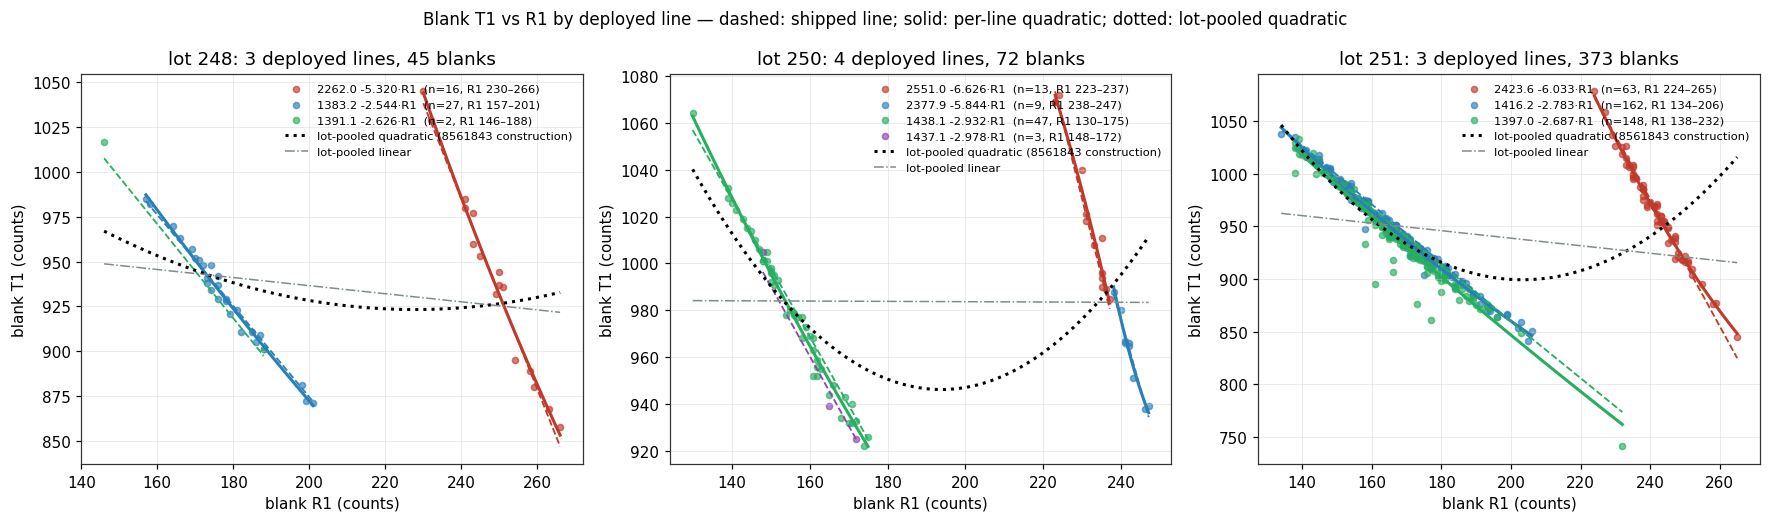

In [5]:
multi_lots = [str(v) for v in multi['lot']]
fig, axes = plt.subplots(1, len(multi_lots), figsize=(5.4 * len(multi_lots), 4.8), squeeze=False)
for ax, lot in zip(axes[0], multi_lots):
    g = blanks[blanks['LotId'] == lot]
    lines_here = line_ledger[(line_ledger['lot'] == lot)].sort_values('analysis_from')
    for color, r in zip(LINE_COLORS, lines_here.itertuples()):
        gb = g[g['line_id'] == r.line_id]
        ax.scatter(gb['R1'], gb['T1'], s=16, alpha=0.65, color=color,
                   label=f'{r.intercept:.1f} {r.slope:+.3f}·R1  (n={r.n_blanks}, R1 {r.R1_min:.0f}–{r.R1_max:.0f})')
        xs = np.linspace(r.R1_min, r.R1_max, 50)
        ax.plot(xs, r.intercept + r.slope * xs, color=color, lw=1.2, ls='--')
        if r.line_id in LINE_FIT:
            ax.plot(xs, np.polyval(LINE_FIT[r.line_id]['quad'], xs), color=color, lw=2.0)
    xs = np.linspace(LOT_FIT[lot]['R1_min'], LOT_FIT[lot]['R1_max'], 200)
    ax.plot(xs, np.polyval(LOT_FIT[lot]['quad'], xs), color='black', lw=2.0, ls=':',
            label='lot-pooled quadratic (8561843 construction)')
    ax.plot(xs, np.polyval(LOT_FIT[lot]['lin'], xs), color='#7F8C8D', lw=1.0, ls='-.',
            label='lot-pooled linear')
    ax.set(xlabel='blank R1 (counts)', ylabel='blank T1 (counts)',
           title=f'lot {lot}: {len(lines_here)} deployed lines, {len(g)} blanks')
    ax.legend(frameon=False, fontsize=7.5, loc='upper right')
fig.suptitle('Blank T1 vs R1 by deployed line — dashed: shipped line; solid: per-line quadratic; '
             'dotted: lot-pooled quadratic', fontsize=11)
fig.tight_layout()
fig.savefig(PLOTS / 'blank_lines_per_lot.png', bbox_inches='tight')
plt.show()

### 2. Network exposure: which sites the pooled construction distorts

Every SPARTAN sample with a shipped Fabs whose deployed line has a blank refit, scored two
ways: (a) extrapolation — is the sample's R1 outside its own line's blank R1 range; (b) the
τ shift, relative to the deployed line, that each alternative construction would impose.
Δ is reported in τ and in Mm⁻¹ (Fabs = 100·τ·A/V).

In [6]:
def tau_from_top(top, T):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.log(np.where((top > 0) & (T > 0), top / T, np.nan))


finite = np.isfinite(samples['Fabs'].to_numpy(float)) & (samples['Volume'] > 0)
print(f'{int(samples["Fabs"].notna().sum() - finite.sum())} sample rows ship Fabs = inf (Volume 0) and are excluded')
net = samples[finite & samples['line_id'].isin(LINE_FIT)].copy()
R, T = net['R1'].to_numpy(float), net['T1'].to_numpy(float)
net['line_R1_min'] = [LINE_FIT[l]['R1_min'] for l in net['line_id']]
net['line_R1_max'] = [LINE_FIT[l]['R1_max'] for l in net['line_id']]
net['below'] = net['R1'] < net['line_R1_min']
net['above'] = net['R1'] > net['line_R1_max']
net['tau_deployed'] = tau_from_top(net['Intercept'].to_numpy(float) + net['Slope'].to_numpy(float) * R, T)
net['tau_line_lin'] = tau_from_top(np.array([np.polyval(LINE_FIT[l]['lin'], r) for l, r in zip(net['line_id'], R)]), T)
net['tau_line_quad'] = tau_from_top(np.array([np.polyval(LINE_FIT[l]['quad'], r) for l, r in zip(net['line_id'], R)]), T)
net['tau_lot_quad'] = tau_from_top(np.array([np.polyval(LOT_FIT[l]['quad'], r) if l in LOT_FIT else np.nan
                                             for l, r in zip(net['LotId'], R)]), T)
for v in ('line_lin', 'line_quad', 'lot_quad'):
    net[f'dtau_{v}'] = net[f'tau_{v}'] - net['tau_deployed']
    net[f'dfabs_{v}'] = net[f'dtau_{v}'] * net['dv']
modal_line = samples[samples['has_line']].groupby('LotId')['line_id'].agg(lambda s: s.value_counts().idxmax())
net['on_non_modal_line'] = net['line_id'] != net['LotId'].map(modal_line)


def q(s, p):
    return float(np.nanquantile(np.abs(s), p))


rows = []
for site, g in net.groupby('Site'):
    n_unfit = int(((samples['Site'] == site) & finite & ~samples['line_id'].isin(LINE_FIT)).sum())
    rows.append({
        'site': site, 'n_samples': len(g), 'n_unfit_line': n_unfit,
        'n_lines': int(g['line_id'].nunique()), 'n_lots': int(g['LotId'].nunique()),
        'frac_non_modal_line': float(g['on_non_modal_line'].mean()),
        'frac_below_R1': float(g['below'].mean()), 'frac_above_R1': float(g['above'].mean()),
        'frac_extrap': float((g['below'] | g['above']).mean()),
        'median_Fabs': float(np.nanmedian(g['Fabs'])),
        'line_quad_med_dtau': q(g['dtau_line_quad'], .5), 'line_quad_p90_dtau': q(g['dtau_line_quad'], .9),
        'line_quad_med_dFabs': q(g['dfabs_line_quad'], .5), 'line_quad_p90_dFabs': q(g['dfabs_line_quad'], .9),
        'lot_quad_med_dtau': q(g['dtau_lot_quad'], .5), 'lot_quad_p90_dtau': q(g['dtau_lot_quad'], .9),
        'lot_quad_med_dFabs': q(g['dfabs_lot_quad'], .5), 'lot_quad_p90_dFabs': q(g['dfabs_lot_quad'], .9),
    })
network = pd.DataFrame(rows).sort_values('frac_extrap', ascending=False).reset_index(drop=True)
network['rank_extrap'] = np.arange(1, len(network) + 1)
network.to_csv(OUT / 'network_site_table.csv', index=False)
net.to_csv(OUT / 'network_per_sample.csv', index=False)
display(network.round(3))

tot = {'n': len(net), 'extrap': float((net['below'] | net['above']).mean()),
       'below': float(net['below'].mean()), 'above': float(net['above'].mean()),
       'non_modal': float(net['on_non_modal_line'].mean()),
       'line_quad_med_dFabs': q(net['dfabs_line_quad'], .5), 'lot_quad_med_dFabs': q(net['dfabs_lot_quad'], .5),
       'line_quad_p90_dFabs': q(net['dfabs_line_quad'], .9), 'lot_quad_p90_dFabs': q(net['dfabs_lot_quad'], .9)}
print(f'\nnetwork ({tot["n"]} samples on fitted lines): {tot["extrap"]*100:.1f}% outside their own line\'s '
      f'blank R1 range ({tot["below"]*100:.1f}% below, {tot["above"]*100:.1f}% above); '
      f'{tot["non_modal"]*100:.1f}% sit on a line that is not their lot\'s modal line.')
print(f'|ΔFabs| vs deployed, network median / p90: per-line quadratic {tot["line_quad_med_dFabs"]:.2f} / '
      f'{tot["line_quad_p90_dFabs"]:.2f} Mm⁻¹; lot-pooled quadratic {tot["lot_quad_med_dFabs"]:.2f} / '
      f'{tot["lot_quad_p90_dFabs"]:.2f} Mm⁻¹')

26 sample rows ship Fabs = inf (Volume 0) and are excluded


,site,n_samples,n_unfit_line,n_lines,n_lots,frac_non_modal_line,frac_below_R1,frac_above_R1,frac_extrap,median_Fabs,line_quad_med_dtau,line_quad_p90_dtau,line_quad_med_dFabs,line_quad_p90_dFabs,lot_quad_med_dtau,lot_quad_p90_dtau,lot_quad_med_dFabs,lot_quad_p90_dFabs,rank_extrap
0,BDDU,68,0,3,2,0.103,0.485,0.000,0.485,42.198,0.006,0.013,0.371,0.978,0.014,0.016,0.747,2.229,1
1,ETAD,239,0,5,3,0.360,0.439,0.000,0.439,47.110,0.004,0.009,0.206,0.494,0.011,0.047,0.535,2.332,2
2,CAHA,59,0,5,2,0.746,0.000,0.390,0.390,2.064,0.005,0.013,0.157,0.566,0.016,0.111,0.676,2.846,3
3,IDBD,54,0,3,2,0.056,0.296,0.000,0.296,29.471,0.004,0.012,0.215,1.575,0.007,0.035,0.432,1.945,4
4,KRSE,44,0,3,2,0.159,0.000,0.250,0.250,11.924,0.004,0.011,0.209,0.716,0.013,0.040,0.666,4.290,5
5,KRUL,122,0,6,3,0.311,0.016,0.230,0.246,6.542,0.004,0.016,0.355,1.111,0.015,0.088,0.839,5.912,6
6,CASH,53,0,4,2,0.283,0.019,0.189,0.208,2.716,0.004,0.014,0.152,0.397,0.015,0.071,0.701,2.247,7
7,AEAZ,89,0,5,2,0.517,0.101,0.090,0.191,28.933,0.007,0.014,0.361,1.504,0.013,0.071,0.734,9.118,8
8,PRFJ,86,7,3,3,0.000,0.000,0.186,0.186,0.635,0.010,0.016,0.224,0.789,0.015,0.063,0.485,2.905,9
9,MXMC,43,14,4,2,0.256,0.116,0.070,0.186,20.774,0.004,0.013,0.189,0.687,0.015,0.087,0.732,5.527,10



network (2998 samples on fitted lines): 14.9% outside their own line's blank R1 range (9.0% below, 5.9% above); 43.3% sit on a line that is not their lot's modal line.
|ΔFabs| vs deployed, network median / p90: per-line quadratic 0.29 / 0.83 Mm⁻¹; lot-pooled quadratic 0.67 / 4.19 Mm⁻¹


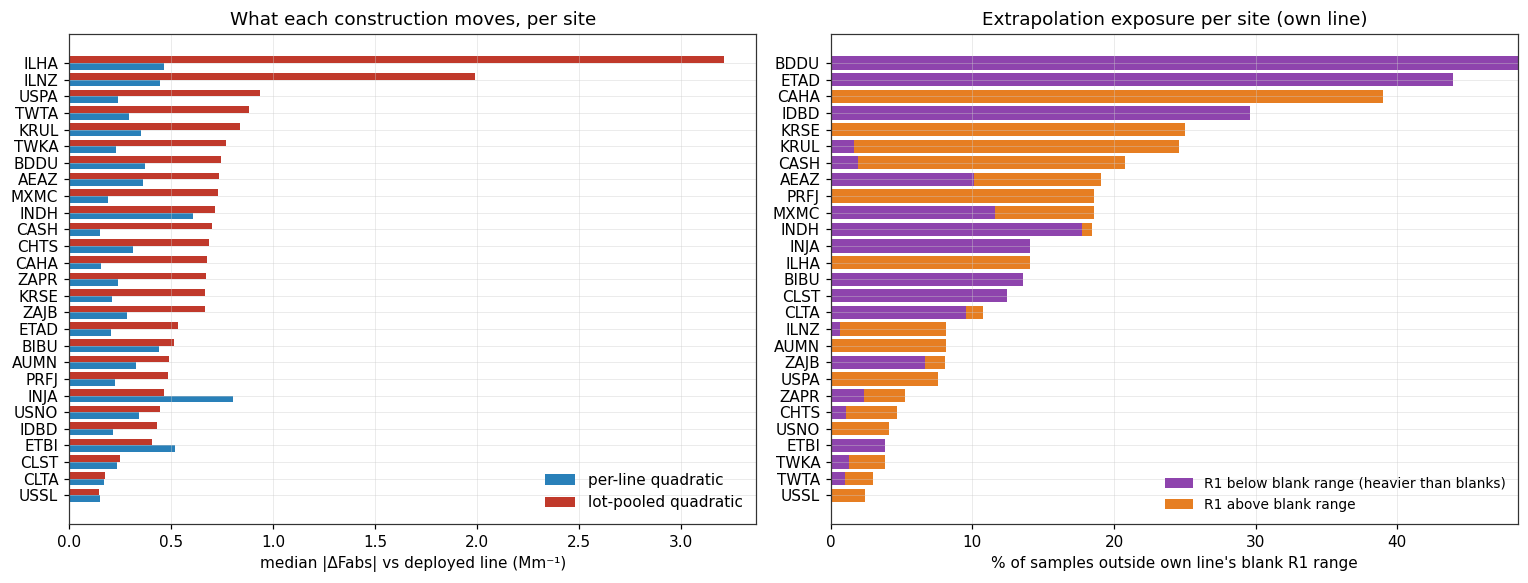

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
ax = axes[0]
order = network.sort_values('lot_quad_med_dFabs', ascending=True)
y = np.arange(len(order))
ax.barh(y - 0.2, order['line_quad_med_dFabs'], height=0.4, color='#2980B9', label='per-line quadratic')
ax.barh(y + 0.2, order['lot_quad_med_dFabs'], height=0.4, color='#C0392B', label='lot-pooled quadratic')
ax.set(yticks=y, yticklabels=order['site'], xlabel='median |ΔFabs| vs deployed line (Mm⁻¹)',
       title='What each construction moves, per site')
ax.legend(frameon=False)
ax = axes[1]
order = network.sort_values('frac_extrap', ascending=True)
y = np.arange(len(order))
ax.barh(y, order['frac_below_R1'] * 100, color='#8E44AD', label='R1 below blank range (heavier than blanks)')
ax.barh(y, order['frac_above_R1'] * 100, left=order['frac_below_R1'] * 100, color='#E67E22',
        label='R1 above blank range')
ax.set(yticks=y, yticklabels=order['site'], xlabel='% of samples outside own line\'s blank R1 range',
       title='Extrapolation exposure per site (own line)')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS / 'network_site_exposure.png', bbox_inches='tight')
plt.show()

### 3. The five explorer targets under four blank-line constructions

For each target and each f(X) configuration, the York fit of prediction vs Fabs/10 with
Fabs recomputed from the filter's own R1/T1 under: the deployed line; the per-line linear
refit; the per-line quadratic (what `hips_lab` serves now); the lot-pooled quadratic (what
the adjudication used). Same filters, same predictions, only the HIPS reduction changes.

In [8]:
EV = pc.load_addis_evaluation()[0]
FIDS = {'addis': EV['ExternalFilterId'].astype(str).tolist()}
for name, _, _ in TARGETS[1:]:
    FIDS[name] = pd.read_csv(REPO / f'calibration_explorer/targets/{name}/reference.csv')[
        'ExternalFilterId'].astype(str).tolist()


def api_run(config, target):
    req = urllib.request.Request(API, json.dumps({**config, 'target': target}).encode(),
                                 {'Content-Type': 'application/json'})
    return json.load(urllib.request.urlopen(req, timeout=900))


def target_rows(name, code):
    sub = (batch[(batch['Site'] == code) & (batch['FilterType'] == 'PM2.5')]
           .drop_duplicates('FilterId').set_index('FilterId'))
    ids = pd.Index(FIDS[name])
    have = ids.isin(sub.index)
    rows = sub.loc[ids[have]].copy()
    rows['dv'] = 100.0 * rows['DepositArea'] / rows['Volume']
    return rows, have


def fabs_variants(rows):
    R, T = rows['R1'].to_numpy(float), rows['T1'].to_numpy(float)
    dv = rows['dv'].to_numpy(float)
    out = {'deployed': hips_lab.tau_variant(rows, 'deployed') * dv,
           'line_lin': hips_lab.tau_variant(rows, 'lot_lin') * dv,      # per-line in the current module
           'line_quad': hips_lab.tau_variant(rows, 'lot_quad') * dv}
    top = np.array([np.polyval(LOT_FIT[l]['quad'], r) if l in LOT_FIT else np.nan
                    for l, r in zip(rows['LotId'], R)])
    out['lot_quad'] = tau_from_top(top, T) * dv
    return out


fit_rows, TARGET_CACHE = [], {}
for cfg_name, cfg in CONFIGS.items():
    for name, code, label in TARGETS:
        d = api_run(cfg, name)
        pred_all, ref_all = np.asarray(d['eval']['pred'], float), np.asarray(d['eval']['ref'], float)
        rows, have = target_rows(name, code)
        assert len(pred_all) == len(FIDS[name]), (name, len(pred_all), len(FIDS[name]))
        pred = pred_all[have]
        assert np.allclose(rows['Fabs'].to_numpy(float), ref_all[have], atol=5e-3), name
        variants = fabs_variants(rows)
        TARGET_CACHE[(cfg_name, name)] = (rows, pred, variants)
        r1min = np.array([LINE_FIT[l]['R1_min'] if l in LINE_FIT else np.nan for l in rows['line_id']])
        for v in VARIANTS:
            fabs = variants[v]
            ok = np.isfinite(fabs) & np.isfinite(pred)
            f = hips_lab.york_site(pred[ok], fabs[ok], code)
            fit_rows.append({'config': cfg_name, 'k': d['k'], 'site': label, 'code': code, 'variant': v,
                             'n_target': len(FIDS[name]), 'n_matched': int(have.sum()), 'n_used': int(ok.sum()),
                             'frac_below_own_line_R1': float(np.nanmean(rows['R1'].to_numpy(float) < r1min)),
                             'n_lines': int(rows['line_id'].nunique()),
                             'median_Fabs': float(np.nanmedian(fabs[ok])), **f})
york = pd.DataFrame(fit_rows)
york.to_csv(OUT / 'five_target_york_by_variant.csv', index=False)


def cell(r):
    return f'{r.slope:.2f}x {r.intercept:+.2f}±{r.intercept_se:.2f}'


wide = (york.assign(fit=[cell(r) for r in york.itertuples()])
        .pivot_table(index=['config', 'site'], columns='variant', values='fit', aggfunc='first')
        [VARIANTS])
wide = wide.reindex([(c, s) for c in CONFIGS for _, _, s in TARGETS])
wide.to_csv(OUT / 'five_target_york_wide.csv')
display(wide)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


variant                                             deployed  \
config                            site                         
winner ocec-440 AIRSpec k=8       Addis     0.93x -1.40±0.18   
                                  Bishoftu  0.92x -0.51±0.46   
                                  Beijing   0.94x +0.65±0.15   
                                  Delhi     1.82x -1.33±0.82   
                                  Pasadena  3.27x -0.26±0.10   
locked ocec-800 AIRSpec k=5       Addis     0.91x -1.87±0.20   
                                  Bishoftu  0.66x -0.38±0.44   
                                  Beijing   1.08x +0.39±0.11   
                                  Delhi     1.83x -1.64±0.56   
                                  Pasadena  2.04x +0.05±0.07   
adjudication ocec-450 AIRSpec k=9 Addis     0.95x -1.51±0.19   
                                  Bishoftu  0.86x -0.39±0.45   
                                  Beijing   0.97x +0.63±0.15   
                                  Delhi     1.83x -1.32±0.86   
                                  Pasadena  3.15x -0.20±0.09   

variant                                             line_lin  \
config                            site                         
winner ocec-440 AIRSpec k=8       Addis     0.93x -1.38±0.18   
                                  Bishoftu  0.91x -0.45±0.44   
                                  Beijing   0.93x +0.69±0.14   
                                  Delhi     1.82x -1.25±0.81   
                                  Pasadena  3.19x -0.19±0.10   
locked ocec-800 AIRSpec k=5       Addis     0.91x -1.84±0.20   
                                  Bishoftu  0.65x -0.33±0.43   
                                  Beijing   1.07x +0.43±0.11   
                                  Delhi     1.83x -1.54±0.55   
                                  Pasadena  1.96x +0.11±0.07   
adjudication ocec-450 AIRSpec k=9 Addis     0.95x -1.48±0.19   
                                  Bishoftu  0.86x -0.34±0.44   
                                  Beijing   0.96x +0.67±0.15   
                                  Delhi     1.83x -1.24±0.85   
                                  Pasadena  3.06x -0.13±0.10   

variant                                            line_quad          lot_quad  
config                            site                                          
winner ocec-440 AIRSpec k=8       Addis     0.92x -1.37±0.18  0.88x -1.17±0.17  
                                  Bishoftu  0.91x -0.44±0.44  0.89x -0.43±0.46  
                                  Beijing   0.93x +0.69±0.15  0.87x +0.70±0.16  
                                  Delhi     1.82x -1.26±0.80  1.78x -1.09±0.83  
                                  Pasadena  3.18x -0.22±0.10  1.01x +0.60±0.11  
locked ocec-800 AIRSpec k=5       Addis     0.90x -1.84±0.20  0.87x -1.66±0.19  
                                  Bishoftu  0.65x -0.33±0.43  0.63x -0.30±0.45  
                                  Beijing   1.07x +0.42±0.11  1.00x +0.45±0.13  
                                  Delhi     1.82x -1.55±0.55  1.80x -1.47±0.57  
                                  Pasadena  1.94x +0.10±0.07  0.55x +0.64±0.07  
adjudication ocec-450 AIRSpec k=9 Addis     0.95x -1.48±0.18  0.91x -1.27±0.17  
                                  Bishoftu  0.86x -0.33±0.44  0.83x -0.31±0.46  
                                  Beijing   0.95x +0.68±0.15  0.88x +0.72±0.17  
                                  Delhi     1.82x -1.25±0.84  1.78x -1.05±0.88  
                                  Pasadena  3.04x -0.15±0.10  0.91x +0.67±0.11

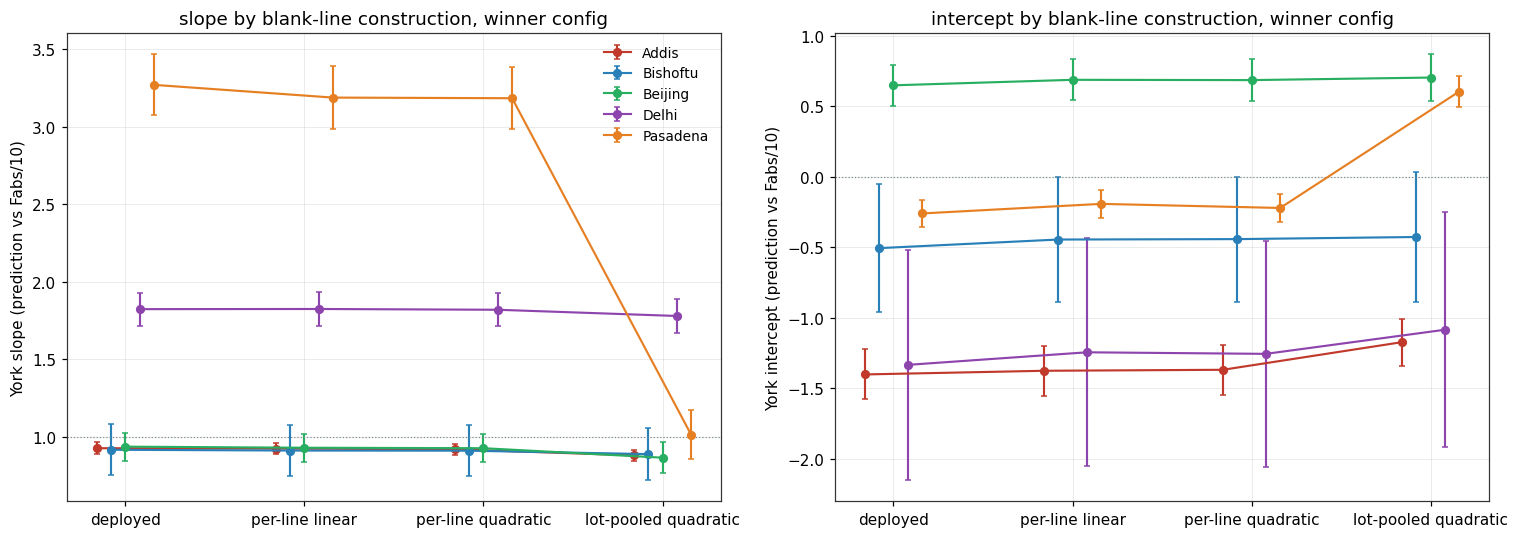

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sub = york[york['config'].str.startswith('winner')]
x = np.arange(len(VARIANTS))
for i, (_, code, label) in enumerate(TARGETS):
    s = sub[sub['site'] == label].set_index('variant').loc[VARIANTS]
    for ax, col in zip(axes, ('slope', 'intercept')):
        ax.errorbar(x + (i - 2) * 0.08, s[col], yerr=s[f'{col}_se'], marker='o', ms=5, capsize=2,
                    color=LINE_COLORS[i], label=label, lw=1.4)
for ax, col, ref in zip(axes, ('slope', 'intercept'), (1.0, 0.0)):
    ax.axhline(ref, color='#7F8C8D', lw=0.8, ls=':')
    ax.set(xticks=x, xticklabels=['deployed', 'per-line linear', 'per-line quadratic', 'lot-pooled quadratic'],
           ylabel=f'York {col} (prediction vs Fabs/10)', title=f'{col} by blank-line construction, winner config')
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PLOTS / 'five_target_york_ladder.png', bbox_inches='tight')
plt.show()

#### The Pasadena correction

`OFFSET_ADJUDICATION_2026-08-23.md` §5 / §5b: "Pasadena's slope anomaly dissolves
entirely (3.15 → 0.91 under the quadratic line)". The rows below reproduce that
number under the adjudication's own configuration and the lot-pooled construction, then
show what the same filters give when each is reduced with the quadratic of *its own*
line's blanks.

In [10]:
rows, pred, variants = TARGET_CACHE[('adjudication ocec-450 AIRSpec k=9', 'uspa')]
adj = york[(york['config'].str.startswith('adjudication')) & (york['site'] == 'Pasadena')].set_index('variant')
print('Pasadena, adjudication config (ocec-450 × AIRSpec, k=9), York prediction vs Fabs/10:')
for v, tag in (('deployed', 'deployed line       '), ('lot_quad', 'lot-pooled quadratic'),
               ('line_lin', 'per-line linear     '), ('line_quad', 'per-line quadratic  ')):
    r = adj.loc[v]
    print(f'  {tag}: {r.slope:.2f} ± {r.slope_se:.2f} x {r.intercept:+.2f} ± {r.intercept_se:.2f}   '
          f'(median Fabs {r.median_Fabs:.2f} Mm⁻¹, n={r.n_used})')

per_line = pd.DataFrame({'line_id': rows['line_id'].to_numpy(), 'R1': rows['R1'].to_numpy(float),
                         **{v: variants[v] for v in VARIANTS}})
pl = per_line.groupby('line_id').agg(n=('R1', 'size'), R1_min=('R1', 'min'), R1_max=('R1', 'max'),
                                     Fabs_deployed=('deployed', 'median'), Fabs_line_quad=('line_quad', 'median'),
                                     Fabs_lot_quad=('lot_quad', 'median'))
pl['lot_quad_over_deployed'] = pl['Fabs_lot_quad'] / pl['Fabs_deployed']
pl['line_quad_over_deployed'] = pl['Fabs_line_quad'] / pl['Fabs_deployed']
pl['blank_R1_range'] = [f'{LINE_FIT[l]["R1_min"]:.0f}–{LINE_FIT[l]["R1_max"]:.0f}' for l in pl.index]
pl.to_csv(OUT / 'pasadena_per_line_breakdown.csv')
display(pl.round(2))
worst = pl['lot_quad_over_deployed'].idxmax()
PASADENA = {'n_worst': int(pl.loc[worst, 'n']), 'n': int(len(rows)), 'worst_line': worst,
            'inflation_pct': float((pl.loc[worst, 'lot_quad_over_deployed'] - 1) * 100),
            'adj': adj}
print(f'\nThe {PASADENA["n_worst"]}/{PASADENA["n"]} Pasadena filters on line {worst} are inflated by '
      f'{PASADENA["inflation_pct"]:.0f}% (median) under the pooled quadratic and by '
      f'{(pl.loc[worst, "line_quad_over_deployed"] - 1) * 100:+.0f}% under their own line\'s quadratic.')

Pasadena, adjudication config (ocec-450 × AIRSpec, k=9), York prediction vs Fabs/10:
  deployed line       : 3.15 ± 0.19 x -0.20 ± 0.09   (median Fabs 4.62 Mm⁻¹, n=158)
  lot-pooled quadratic: 0.91 ± 0.15 x +0.67 ± 0.11   (median Fabs 5.82 Mm⁻¹, n=158)
  per-line linear     : 3.06 ± 0.19 x -0.13 ± 0.10   (median Fabs 4.49 Mm⁻¹, n=158)
  per-line quadratic  : 3.04 ± 0.19 x -0.15 ± 0.10   (median Fabs 4.61 Mm⁻¹, n=158)


,n,R1_min,R1_max,Fabs_deployed,Fabs_line_quad,Fabs_lot_quad,lot_quad_over_deployed,line_quad_over_deployed,blank_R1_range
line_id,,,,,,,,,
248|I=1383.200|S=-2.5440,14,162.0,212.0,3.27,3.16,4.70,1.44,0.97,157–201
251|I=1416.200|S=-2.7830,88,146.0,219.0,4.70,4.61,5.32,1.13,0.98,134–206
251|I=2423.600|S=-6.0330,56,237.0,272.0,4.84,5.23,8.72,1.80,1.08,224–265



The 56/158 Pasadena filters on line 251|I=2423.600|S=-6.0330 are inflated by 80% (median) under the pooled quadratic and by +8% under their own line's quadratic.


#### Addis under the same correction

The adjudication's Addis quadratic number, −1.27 ± 0.17, came from the same pooled
construction (Addis filters span lots 248, 251 and 253; lots 248 and 251 are multi-line).

In [11]:
addis = york[york['site'] == 'Addis'].set_index(['config', 'variant'])
print('Addis York intercepts by construction:')
for cfg_name in CONFIGS:
    parts = []
    for v in VARIANTS:
        r = addis.loc[(cfg_name, v)]
        parts.append(f'{v} {r.intercept:+.2f}±{r.intercept_se:.2f}')
    print(f'  {cfg_name:36s} ' + ' | '.join(parts))
rows_a, _, _ = TARGET_CACHE[('winner ocec-440 AIRSpec k=8', 'addis')]
print('\nAddis matched filters by deployed line:')
print(rows_a.groupby(['LotId', 'Intercept', 'Slope']).size().to_string())

Addis York intercepts by construction:
  winner ocec-440 AIRSpec k=8          deployed -1.40±0.18 | line_lin -1.38±0.18 | line_quad -1.37±0.18 | lot_quad -1.17±0.17
  locked ocec-800 AIRSpec k=5          deployed -1.87±0.20 | line_lin -1.84±0.20 | line_quad -1.84±0.20 | lot_quad -1.66±0.19
  adjudication ocec-450 AIRSpec k=9    deployed -1.51±0.19 | line_lin -1.48±0.19 | line_quad -1.48±0.18 | lot_quad -1.27±0.17

Addis matched filters by deployed line:
LotId  Intercept  Slope 
248    1383.2     -2.544     27
       2262.0     -5.320      7
251    1397.0     -2.687    106
       1416.2     -2.783     79
253    1375.1     -2.608     14


### 4. Lines that cannot be audited from local files

Two references in the explorer rest on lines whose blanks are not in any local file, or
whose assignment to a filter is inferred rather than shipped.

In [12]:
recon = pd.read_csv('output/tables/hips/reconstructed_fabs.csv')
etbi_recon = recon[(recon['Site'] == 'ETBI') & ~recon['looks_like_blank']]
etbi_hold = pd.read_csv(REPO / 'calibration_explorer/targets/etbi_reconstructed_holdout/reference.csv')
etbi_line = etbi_recon.groupby(['CalibrationIntercept', 'CalibrationSlope', 'CalibrationLineSource']).size()
amod = pd.read_csv(pc.PATHS.etad_dir.parent / 'CSU_AMOD' / 'csu_amod_HIPS_Batch_54.csv', encoding='cp1252')
lot245_batch = int((batch['LotId'] == '245').sum())
lot245_raw = int((raw_pull['ExternalLotId'].astype(str) == '245').sum())
no_line = samples[~samples['has_line']]
unaudit = pd.DataFrame([
    {'reference': 'ETBI reconstructed holdout (n=%d)' % len(etbi_hold),
     'line': '; '.join(f'{i:.1f} {s:+.3f}·R1 ({src}, {n} filters)' for (i, s, src), n in etbi_line.items()),
     'how the line was chosen': 'inferred from analysis timestamp against the shipped lines\' active dates '
                                '(reconstruct_hips_fabs.py: dated_schedule); the shipped export carries no line for these filters',
     'blanks available locally': '; '.join(
         f'{line_ledger.set_index("line_id").loc[hips_lab._line_id(hips_lab._line_key(251, i, s)), "n_blanks"]} blanks on {i:.1f} {s:+.3f}·R1'
         for (i, s, _src), _n in etbi_line.items()) + ' (the blanks exist; the assignment is the inference)',
     'auditable': 'assignment: no; line shape: yes'},
    {'reference': f'Adama CSU-AMOD batch 54 (n={len(amod)}, lot {amod["LotId"].iloc[0]})',
     'line': f'{amod["Intercept"].iloc[0]:.1f} {amod["Slope"].iloc[0]:+.3f}·R1 (sample R1 {amod["R1"].min():.0f}–{amod["R1"].max():.0f})',
     'how the line was chosen': 'shipped on the batch-54 rows; hips.CalibrationSets ids 2 and 11 (move, collimator) '
                                'per scripts/AQRC_DB_NOTES.md',
     'blanks available locally': f'none: {lot245_batch} lot-245 rows in the SPARTAN export, {lot245_raw} in the raw hips.Results pull',
     'auditable': 'no'},
    {'reference': f'SPARTAN samples with no deployed line (lots {sorted(no_line["LotId"].unique())})',
     'line': 'Intercept/Slope empty on the row',
     'how the line was chosen': 'unknown; Fabs shipped anyway' if no_line['Fabs'].notna().any() else 'no Fabs shipped',
     'blanks available locally': f'{int((is_blank & ~batch["has_line"]).sum())} blanks, also without a line',
     'auditable': 'no'},
])
unaudit.to_csv(OUT / 'unauditable_lines.csv', index=False)
with pd.option_context('display.max_colwidth', None):
    display(unaudit)
print(f'samples without a deployed line: {len(no_line)} rows, {no_line["Site"].nunique()} sites, '
      f'{int(no_line["Fabs"].notna().sum())} with a shipped Fabs')

,reference,line,how the line was chosen,blanks available locally,auditable
0,ETBI reconstructed holdout (n=14),"1397.0 -2.687·R1 (dated_schedule, 14 filters)",inferred from analysis timestamp against the shipped lines' active dates (reconstruct_hips_fabs.py: dated_schedule); the shipped export carries no line for these filters,148 blanks on 1397.0 -2.687·R1 (the blanks exist; the assignment is the inference),assignment: no; line shape: yes
1,"Adama CSU-AMOD batch 54 (n=5, lot 245)",1464.2 -2.554·R1 (sample R1 131–164),"shipped on the batch-54 rows; hips.CalibrationSets ids 2 and 11 (move, collimator) per scripts/AQRC_DB_NOTES.md","none: 0 lot-245 rows in the SPARTAN export, 0 in the raw hips.Results pull",no
2,"SPARTAN samples with no deployed line (lots ['241', '241a', '251', '253'])",Intercept/Slope empty on the row,no Fabs shipped,"7 blanks, also without a line",no


samples without a deployed line: 56 rows, 8 sites, 0 with a shipped Fabs


### 5. The rule for the explorer

**A blank line is keyed on (lot, Intercept, Slope) — never on lot.** The lot is the PTFE
manufacturing batch; the calibration line is an instrument state, and one lot is
re-calibrated every time the instrument changes. Blanks from different calibration states
of the same lot do not describe one response curve, so any refit — linear, quadratic,
anything — must use only the blanks reduced with the same deployed (Intercept, Slope) as the
sample. A sample's "blank R1 range" is its own line's range, and a line with fewer than
five local blanks gets no refit and is flagged rather than borrowed from the lot. This is
what `calibration_explorer/hips_lab.py` does now (`_line_key`, `blank_lines()`,
`tau_variant`, `site_rows`); the 8561843 lot-keyed version must not be quoted.

## Takeaways

- **The lot is the wrong key.** A lot is re-calibrated at every instrument event, and the
  instrument's gain moves the blanks' R1 band with it (lot 251: 224–265 → 134–206 → 138–232).
  Pooling blanks across those states fits the instrument's history, not the filter response;
  the resulting curve is wrong exactly where a line's samples live. Per-line refits are
  4–10 counts rms; pooled ones 31–43. The shipped line is, to within ~1 count rms, the
  OLS line of its own blanks — so "deployed" and "per-line linear" are the same object.
- **Pasadena's slope anomaly is not a blank-line artifact.** The §5b "3.15 → 0.91" was 56
  filters reduced with a curve that has no blanks at their R1; on their own line the slope
  is 3.04 ± 0.19 (adjudication config), 3.18 ± 0.20 (winner), 1.94 ± 0.14 (locked). Its
  dependence on the f(X) configuration (3.2 vs 1.9) is a calibration-side question, not a
  HIPS-side one — Pasadena goes back on the slope-anomaly list with Delhi.
- **Addis's intercept is blank-line-insensitive to the third decimal.** Deployed, per-line
  linear and per-line quadratic agree within 0.03 µg/m³ in all three configurations. The
  "~15% blank-line share" quoted in §5 came from the pooled curve and should be read as ~2%.
  The adjudication's *conclusion* (the Addis intercept is real) stands; its quantification
  of the blank-line mechanism does not.
- **The extrapolation exposure is heavier than the 08-23 numbers.** Per-line ranges are
  narrower than pooled lot ranges, so more samples sit outside them: Addis 44% below (was
  36%), Delhi 18% (was 14%). These are the samples whose Fabs rests on a straight-line
  extrapolation past the heaviest blank — the ftir_37 loading question, now with the right
  denominator.
- **Which sites the pooled construction hurts is predictable from the blank R1 layout**:
  any site whose samples sit on an early (high-gain, R1 > 220) line of a multi-line lot —
  ILHA, ILNZ, Pasadena, TWTA, KRUL — gets Fabs shifted by 1–3 Mm⁻¹ median, up to 9 Mm⁻¹ at
  p90. Sites on single-line lots (ETBI, USSL, CLTA) barely move either way.
- **Two references stay provisional.** The ETBI reconstructed holdout's line is a dated
  inference (its blanks exist, the assignment does not appear in any shipped file); Adama's
  lot-245 line cannot be checked at all until its blanks are pulled from
  `hips.CalibrationSetFilters` (sets 2 and 11).
- **Explorer rule**: blank lines keyed on (lot, Intercept, Slope); refit only from blanks on
  the same key; report a sample's extrapolation against its own line; never borrow a lot's
  other blanks. `hips_lab.py` at HEAD does this; the 8561843 tab output is superseded.

## Limits

- Blank R1 ranges come from the batch export's FB/LB rows, not the lab's full calibration
  set; a line may have been fitted on more blanks than we see, so "outside the blank range"
  is an upper bound on extrapolation as the lab experienced it.
- Per-line quadratics are fitted on 9–162 blanks spanning 9–94 R1 counts; the curvature
  signs (all convex but one) are weak and change nothing at the sample level (median
  |ΔFabs| 0.29 Mm⁻¹). The test here is "does the construction matter", not "is the response
  quadratic" — that still needs blanks at loaded-filter R1, i.e. an independent EC.
- Three lines (241a, 248's 1391.1 line, 250's 1437.1 line) have 2–3 blanks and get no
  refit; their 49 samples (CLST, ILHA, ILNZ, MXMC, PRFJ) are scored only under the deployed
  line and are absent from the network table's Δ columns.
- York σ_x uses per-site HIPS uncertainty models fitted on shipped Fabs; recomputed Fabs
  reuse the same σ(F) form. ETBI has no uncertainty rows and borrows the pooled model.
- The locked configuration's Pasadena slope (2.04 deployed) differs from the winner's (3.27)
  because f(X) differs, not because of anything HIPS-side; the notebook does not adjudicate
  between the two calibrations.
- The ETBI holdout and Adama rows are inventory statements: nothing here recomputes them.